# EP1 — Sistema de Atendimento com Clientes Impacientes

**ACH2158 — Simulação de Sistemas Complexos**

**Autores:**
- Guilherme — NUSP: 14677300
- Mateus Esposte — NUSP: 13862650

---

Este notebook implementa o **Problema do balcão de atendimento com fila** (clientes
impacientes), descrito nos slides da disciplina, e resolve os dois subproblemas
pedidos no enunciado do EP1.

**Parâmetros fixos (enunciado):**

| Parâmetro | Valor | Significado |
|-----------|-------|-------------|
| `T` | 120 min | tempo total de funcionamento do balcão |
| `λ` (lam) | 4 /min | taxa média de chegada de clientes |
| `ν` (nu) | 0.5 /min | taxa média de atendimento por guichê (tempo médio = 2 min) |
| `n` | 5 | número de guichês (Subproblema 1) |
| `NB` | 500 | tamanho do bloco (batch) do controle de convergência |
| limiar | 0.002 | amplitude máxima do IC 95% de µ̂_W para parar |

> **Nota sobre o Problema 1 (sem fila):** o EP1 trata apenas do sistema **com
> fila**. O Problema 1 dos slides (sem fila, tempo de atendimento constante) é
> apenas o material teórico introdutório e, por isso, não é reimplementado aqui.
> Todo o notebook trata do sistema com fila e desistência probabilística.

## 1. Importações e configuração

In [ ]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

# Semente para reprodutibilidade (altere/remova para gerar novas rodadas)
random.seed(42)
np.random.seed(42)

# Parâmetros fixos do enunciado
T   = 120.0   # tempo total de funcionamento (min)
LAM = 4.0     # taxa de chegada (clientes/min)
NU  = 0.5     # taxa de atendimento por guichê (1/min) -> tempo médio de atend. = 2 min
NB  = 500     # tamanho do bloco do controle de convergência
LIMIAR = 0.002  # amplitude máxima desejada do IC 95% de µ̂_W

# --- Definição de "tempo de serviço" (ver nota abaixo sobre a ambiguidade) ---
# True  -> tempo de serviço = término do atendimento - CHEGADA do cliente
#          (INCLUI a espera na fila). É a definição textual do enunciado e do
#          pseudocódigo ("término - chegada").
# False -> tempo de serviço = apenas a duração do atendimento ~ Exp(nu)
#          (EXCLUI a espera). Reproduz o eixo da Figura 3 de exemplo (~2 min).
INCLUIR_ESPERA = True


## 2. Modelo e simulação de uma única sequência (Funções auxiliares)

**Regras do modelo (slides):**

- Os clientes chegam em instantes cujos intervalos seguem distribuição
  Exponencial de taxa `λ`.
- O tempo de atendimento de cada cliente em um guichê é Exponencial de taxa `ν`.
- Quando um cliente chega e há guichê livre, é atendido imediatamente.
- Quando todos os guichês estão ocupados, forma-se uma fila FIFO. Um cliente que
  chega observa o comprimento `r` da fila e **desiste** (vai embora sem entrar)
  com probabilidade `p_r = r / (r + n)`.
- Quem entra na fila é sempre atendido, mesmo que o atendimento termine após `T`.

> **Parametrização da Exponencial:** os slides recomendam
> `np.random.exponential(scale = 1/λ)`, pois o `numpy` parametriza pela *escala*
> (= 1/taxa). Aqui usamos `random.expovariate(taxa)`, que é **equivalente em
> distribuição** e mais rápido em laços com milhões de sorteios:
> `random.expovariate(λ)` gera valores com média `1/λ`, idêntico a
> `np.random.exponential(scale=1/λ)`.

**Definição de "tempo de serviço" (enunciado):** intervalo desde a **chegada** do
cliente até o **término** do seu atendimento no guichê (inclui, portanto, o tempo
de espera na fila).

In [ ]:
def gera_chegadas(T, lam):
    """Gera o vetor de instantes de chegada dentro de [0, T]."""
    Tcheg = []
    Tu = 0.0
    while True:
        Tu += random.expovariate(lam)   # equivalente a np.random.exponential(scale=1/lam)
        if Tu <= T:
            Tcheg.append(Tu)
        else:
            break
    return Tcheg


In [ ]:
def simula_uma_sequencia(Tcheg, n, nu, incluir_espera=True):
    """Simula uma única sequência de atendimentos com fila.

    Retorna:
        w      : proporção de clientes que desistiram = y / (x + y)
        tmean  : tempo médio de serviço dos clientes atendidos
        tmax   : tempo máximo de serviço dos clientes atendidos

    Se incluir_espera=True : tempo de serviço = término - chegada (inclui espera).
    Se incluir_espera=False: tempo de serviço = duração do atendimento ~ Exp(nu).
    """
    gtdisp = [0.0] * n        # instante em que cada guichê fica livre
    fila = deque()            # FIFO com os instantes de chegada dos clientes na fila
    x = 0                     # clientes atendidos
    y = 0                     # clientes que desistiram
    tempos = []               # tempo de serviço de cada cliente atendido

    i = 0                     # índice do próximo cliente a chegar (0-based)
    n_cheg = len(Tcheg)

    while i < n_cheg or fila:
        # 1o guichê a ficar livre (menor gtdisp). argmin manual (n pequeno, mais rápido)
        j = 0
        t_libera = gtdisp[0]
        for k in range(1, n):
            if gtdisp[k] < t_libera:
                t_libera = gtdisp[k]
                j = k

        t_cheg = Tcheg[i] if i < n_cheg else float('inf')

        if t_libera <= t_cheg:
            # Caso 1: um guichê fica livre antes (ou junto) da próxima chegada
            a = random.expovariate(nu)          # tempo de atendimento ~ Exp(nu)
            if not fila:
                # Caso 1a: cliente que chega é atendido imediatamente (não espera)
                gtdisp[j] = t_cheg + a
                x += 1                           # <- cliente atendido (corrige omissão do slide)
                tempos.append(a)                 # espera = 0, então término-chegada = a
                i += 1
            else:
                # Caso 1b: o 1o da fila é atendido pelo guichê que acabou de liberar
                chegada = fila.popleft()
                gtdisp[j] = t_libera + a
                x += 1
                if incluir_espera:
                    tempos.append((t_libera + a) - chegada)  # término - chegada
                else:
                    tempos.append(a)                          # só o atendimento
        else:
            # Caso 2: nenhum guichê fica livre antes da próxima chegada
            if not fila:
                # Caso 2a: fila vazia -> o cliente entra na fila
                fila.append(t_cheg)
            else:
                # Caso 2b: decide desistir (prob p) ou entrar na fila (prob 1-p)
                r = len(fila)
                p = r / (r + n)
                if random.random() < p:
                    y += 1                        # desiste
                else:
                    fila.append(t_cheg)           # entra na fila
            i += 1

    w = y / (x + y) if (x + y) > 0 else 0.0
    if tempos:
        tmean = sum(tempos) / len(tempos)
        tmax = max(tempos)
    else:
        tmean = 0.0
        tmax = 0.0
    return w, tmean, tmax


## 3. Inferência (Teorema do Limite Central) e controle de convergência

Para uma amostra de $N$ simulações independentes $w_1, \dots, w_N$:

$$\hat{\mu}_W = \frac{1}{N}\sum_{i=1}^N w_i, \qquad
  \hat{\sigma}_W = \sqrt{\frac{\sum_{i=1}^N (w_i-\hat{\mu}_W)^2}{N-1}}$$

O erro padrão da média é $\mathrm{ep}(\hat{\mu}_W) = \hat{\sigma}_W/\sqrt{N}$ e o
intervalo de 95% de confiança é $\hat{\mu}_W \pm 1.96\,\mathrm{ep}(\hat{\mu}_W)$,
com amplitude $2 \times 1.96 \times \mathrm{ep}(\hat{\mu}_W)$.

**Controle de convergência:** rodamos blocos de tamanho `NB = 500` e paramos
quando a amplitude do IC 95% de $\hat{\mu}_W$ fica **abaixo de 0.002**.

In [ ]:
def estatisticas(amostra, z=1.96):
    """Retorna média, desvio, erro padrão, IC e amplitude do IC de uma amostra."""
    a = np.asarray(amostra, dtype=float)
    N = len(a)
    media = a.mean()
    desvio = a.std(ddof=1) if N > 1 else 0.0
    ep = desvio / np.sqrt(N) if N > 0 else np.inf
    return {
        "N": N, "media": media, "desvio": desvio, "ep": ep,
        "IC": (media - z*ep, media + z*ep), "amplitude": 2*z*ep,
    }


def simula_com_convergencia(T, lam, nu, n, NB=500, limiar=0.002,
                            max_N=100_000, incluir_espera=True, verbose=True):
    """Roda simulações em blocos de NB até a amplitude do IC95% de W < limiar.

    Retorna arrays W, Tmean, Tmax (um valor por simulação).
    """
    W, Tmean, Tmax = [], [], []
    while True:
        for _ in range(NB):
            Tcheg = gera_chegadas(T, lam)
            w, tm, tx = simula_uma_sequencia(Tcheg, n, nu, incluir_espera)
            W.append(w); Tmean.append(tm); Tmax.append(tx)
        st = estatisticas(W)
        if verbose:
            print(f"N={st['N']:>6d}  µ̂_W={st['media']:.4f}  "
                  f"amplitude IC95={st['amplitude']:.5f}")
        if st["amplitude"] < limiar or st["N"] >= max_N:
            break
    return np.array(W), np.array(Tmean), np.array(Tmax)


---
# Subproblema 1 — n = 5 guichês

Executa o controle de convergência e produz os resultados pedidos:
gráfico de convergência (Fig. 1), histogramas de W, tempo médio e tempo máximo
(Figs. 2–4), médias finais, Pr(tmax > 13) e o quantil 0.95 de W.

In [5]:
n1 = 5
W, Tmean, Tmax = simula_com_convergencia(T, LAM, NU, n1, NB=NB, limiar=LIMIAR,
                                         incluir_espera=INCLUIR_ESPERA)
N = len(W)
print(f"\nConvergência atingida com N = {N} simulações.")


N=   500  µ̂_W=0.3732  amplitude IC95=0.00701
N=  1000  µ̂_W=0.3727  amplitude IC95=0.00493


N=  1500  µ̂_W=0.3730  amplitude IC95=0.00405
N=  2000  µ̂_W=0.3729  amplitude IC95=0.00356


N=  2500  µ̂_W=0.3729  amplitude IC95=0.00315
N=  3000  µ̂_W=0.3730  amplitude IC95=0.00292


N=  3500  µ̂_W=0.3730  amplitude IC95=0.00269
N=  4000  µ̂_W=0.3733  amplitude IC95=0.00250


N=  4500  µ̂_W=0.3730  amplitude IC95=0.00235
N=  5000  µ̂_W=0.3730  amplitude IC95=0.00223


N=  5500  µ̂_W=0.3729  amplitude IC95=0.00212
N=  6000  µ̂_W=0.3730  amplitude IC95=0.00202


N=  6500  µ̂_W=0.3730  amplitude IC95=0.00194

Convergência atingida com N = 6500 simulações.


### Figura 1 — Convergência de µ̂_W (média cumulativa e IC 95%)

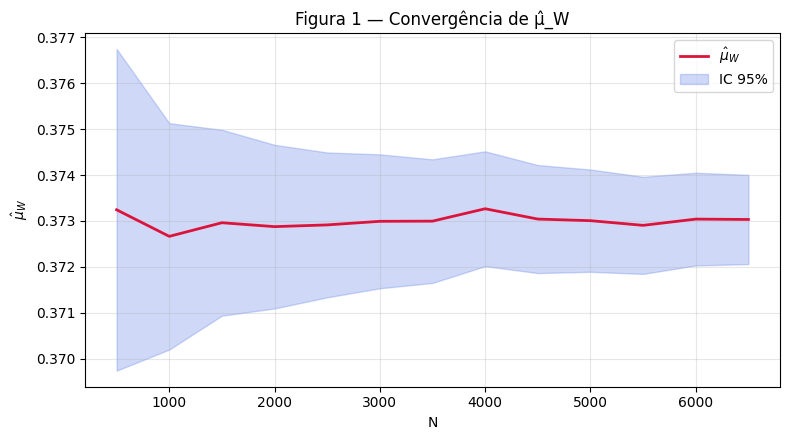

In [6]:
# Média cumulativa e IC 95% para cada k em {500, 1000, ..., N}
ks = np.arange(NB, N + 1, NB)
mu_cum, li_cum, ls_cum = [], [], []
for k in ks:
    st = estatisticas(W[:k])
    mu_cum.append(st["media"])
    li_cum.append(st["IC"][0])
    ls_cum.append(st["IC"][1])
mu_cum = np.array(mu_cum); li_cum = np.array(li_cum); ls_cum = np.array(ls_cum)

plt.figure(figsize=(8, 4.5))
plt.plot(ks, mu_cum, color='crimson', lw=2, label=r'$\hat{\mu}_W$')
plt.fill_between(ks, li_cum, ls_cum, color='royalblue', alpha=0.25, label='IC 95%')
plt.xlabel("N")
plt.ylabel(r'$\hat{\mu}_W$')
plt.title("Figura 1 — Convergência de µ̂_W")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Figura 2 — Histograma de W (proporção de desistentes)

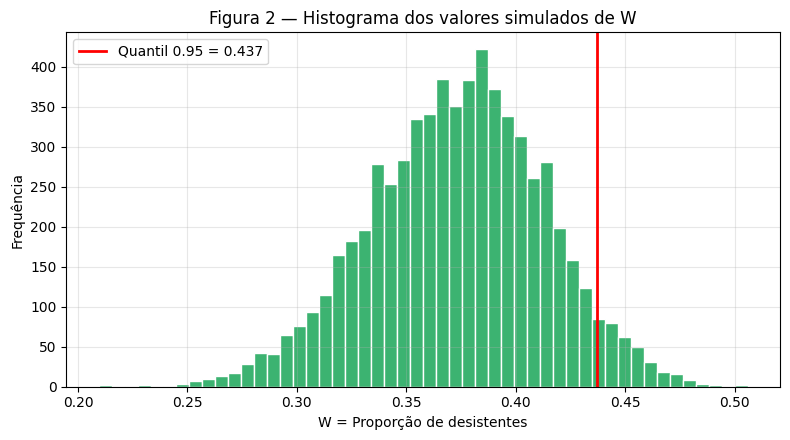

In [7]:
q95_W = np.quantile(W, 0.95)

plt.figure(figsize=(8, 4.5))
plt.hist(W, bins=50, color='mediumseagreen', edgecolor='white')
plt.axvline(q95_W, color='red', lw=2, label=f'Quantil 0.95 = {q95_W:.3f}')
plt.xlabel("W = Proporção de desistentes")
plt.ylabel("Frequência")
plt.title("Figura 2 — Histograma dos valores simulados de W")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Figura 3 — Histograma dos tempos médios de serviço

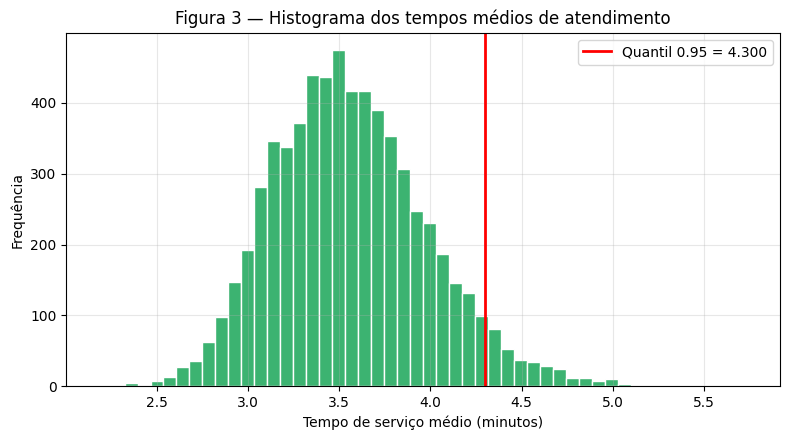

In [8]:
q95_tmean = np.quantile(Tmean, 0.95)

plt.figure(figsize=(8, 4.5))
plt.hist(Tmean, bins=50, color='mediumseagreen', edgecolor='white')
plt.axvline(q95_tmean, color='red', lw=2, label=f'Quantil 0.95 = {q95_tmean:.3f}')
plt.xlabel("Tempo de serviço médio (minutos)")
plt.ylabel("Frequência")
plt.title("Figura 3 — Histograma dos tempos médios de atendimento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Figura 4 — Histograma dos tempos máximos de serviço

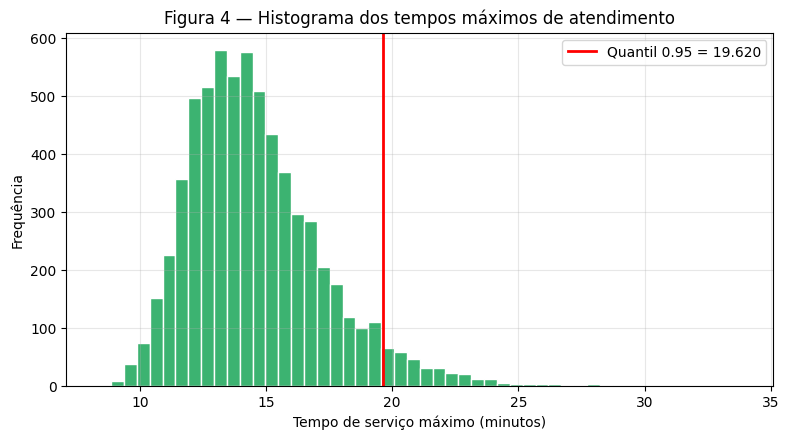

In [9]:
q95_tmax = np.quantile(Tmax, 0.95)

plt.figure(figsize=(8, 4.5))
plt.hist(Tmax, bins=50, color='mediumseagreen', edgecolor='white')
plt.axvline(q95_tmax, color='red', lw=2, label=f'Quantil 0.95 = {q95_tmax:.3f}')
plt.xlabel("Tempo de serviço máximo (minutos)")
plt.ylabel("Frequência")
plt.title("Figura 4 — Histograma dos tempos máximos de atendimento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Médias finais e demais resultados pedidos

In [10]:
mu_W     = W.mean()
mu_tmean = Tmean.mean()
mu_tmax  = Tmax.mean()

pr_tmax_gt_13 = np.mean(Tmax > 13)     # Pr(tmax > 13)
ws = np.quantile(W, 0.95)              # valor ws tal que Pr(W > ws) < 5%

print("========== RESULTADOS — SUBPROBLEMA 1 (n = 5) ==========")
print(f"N (simulações)                        : {N}")
print(f"µ̂_W    (média das proporções de desist.): {mu_W:.4f}")
print(f"µ̂_tmean(média dos tempos médios)        : {mu_tmean:.4f} min")
print(f"µ̂_tmax (média dos tempos máximos)       : {mu_tmax:.4f} min")
print(f"Pr(tmax > 13)                          : {pr_tmax_gt_13:.4f}")
print(f"ws  (quantil 0.95 de W, Pr(W>ws)<5%)   : {ws:.4f}")


========== RESULTADOS — SUBPROBLEMA 1 (n = 5) ==========
N (simulações)                        : 6500
µ̂_W    (média das proporções de desist.): 0.3730
µ̂_tmean(média dos tempos médios)        : 3.5610 min
µ̂_tmax (média dos tempos máximos)       : 14.6035 min
Pr(tmax > 13)                          : 0.7023
ws  (quantil 0.95 de W, Pr(W>ws)<5%)   : 0.4371


### Discussão (Subproblema 1)

Com a configuração dada ($\lambda = 4$ chegadas/min e capacidade de atendimento
$n \times \nu = 5 \times 0.5 = 2.5$ atendimentos/min), o sistema recebe clientes a
uma taxa bem maior do que consegue atender. O resultado é uma proporção média de
desistências elevada — da ordem de **37%** — e um quantil 0.95 de $W$ ainda mais
alto (frações de dias em que quase metade dos clientes vai embora).

Do ponto de vista de satisfação do cliente, essa configuração é **insatisfatória**:
em torno de um a cada três clientes desiste sem ser atendido, e nos piores cenários
(quantil 0.95) essa fração é ainda maior. Além disso, os tempos máximos de serviço
podem chegar a dezenas de minutos. Isso motiva o Subproblema 2: quantos guichês
seriam necessários para garantir um nível de serviço aceitável.

*(Os números exatos aparecem impressos na célula acima; ajuste o texto conforme a
rodada de vocês.)*

---
# Subproblema 2 — número mínimo de guichês

**Objetivo:** encontrar o menor número de guichês $n$ tal que
$$\Pr(W \le 20\%) \ge 0.95,$$
ou seja, a proporção $W$ de clientes que desistem fique abaixo de 20% com
probabilidade de pelo menos 0.95. Isso equivale a exigir que o **quantil 0.95 de
$W$ seja $\le 0.20$**.

Para cada valor de $n$ usamos o mesmo critério de convergência do Subproblema 1.

In [11]:
def quantil95_W_para_n(n, T=T, lam=LAM, nu=NU, NB=NB, limiar=LIMIAR):
    """Roda o controle de convergência para um dado n e retorna (q95_W, N, mu_W)."""
    W, _, _ = simula_com_convergencia(T, lam, nu, n, NB=NB, limiar=limiar,
                                      incluir_espera=INCLUIR_ESPERA, verbose=False)
    return np.quantile(W, 0.95), len(W), W.mean(), W


ns = list(range(5, 15))   # testa n = 5, 6, ..., 14
q95_por_n = []
mu_por_n = []
W_por_n = {}

print(f"{'n':>3} | {'N':>6} | {'µ̂_W':>7} | {'q95(W)':>7} | Pr(W<=0.20)>=0.95 ?")
print("-" * 55)
n_escolhido = None
for n in ns:
    q95, Nn, muW, Wn = quantil95_W_para_n(n)
    q95_por_n.append(q95)
    mu_por_n.append(muW)
    W_por_n[n] = Wn
    ok = q95 <= 0.20
    if ok and n_escolhido is None:
        n_escolhido = n
    print(f"{n:>3} | {Nn:>6} | {muW:>7.4f} | {q95:>7.4f} | {'SIM' if ok else 'não'}")

print(f"\nMenor n que satisfaz Pr(W <= 20%) >= 0.95:  n = {n_escolhido}")


  n |      N |    µ̂_W |  q95(W) | Pr(W<=0.20)>=0.95 ?
-------------------------------------------------------


  5 |   6000 |  0.3726 |  0.4366 | não


  6 |   6000 |  0.2696 |  0.3340 | não


  7 |   5000 |  0.1840 |  0.2441 | não


  8 |   3500 |  0.1164 |  0.1673 | SIM


  9 |   2500 |  0.0695 |  0.1115 | SIM


 10 |   1500 |  0.0397 |  0.0719 | SIM


 11 |   1000 |  0.0202 |  0.0418 | SIM
 12 |    500 |  0.0098 |  0.0233 | SIM


 13 |    500 |  0.0047 |  0.0145 | SIM
 14 |    500 |  0.0022 |  0.0083 | SIM

Menor n que satisfaz Pr(W <= 20%) >= 0.95:  n = 8


### Figura 5 — Quantil 0.95 de W em função de n (forma 'elegante')

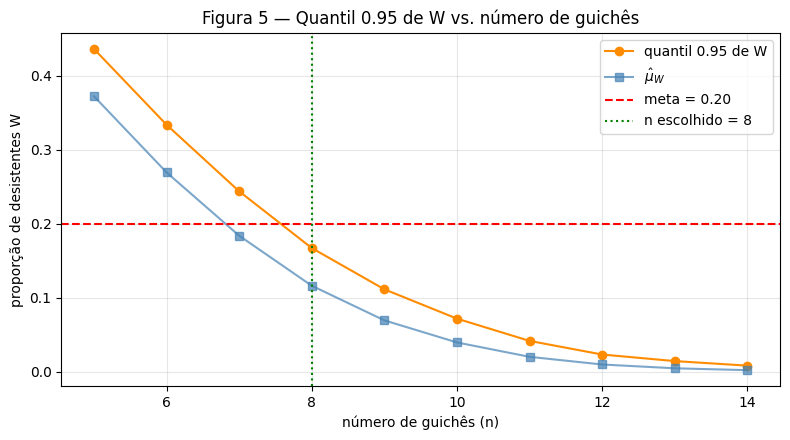

In [12]:
plt.figure(figsize=(8, 4.5))
plt.plot(ns, q95_por_n, marker='o', color='darkorange', label='quantil 0.95 de W')
plt.plot(ns, mu_por_n, marker='s', color='steelblue', label=r'$\hat{\mu}_W$', alpha=0.7)
plt.axhline(0.20, color='red', ls='--', lw=1.5, label='meta = 0.20')
if n_escolhido is not None:
    plt.axvline(n_escolhido, color='green', ls=':', lw=1.5,
                label=f'n escolhido = {n_escolhido}')
plt.xlabel("número de guichês (n)")
plt.ylabel("proporção de desistentes W")
plt.title("Figura 5 — Quantil 0.95 de W vs. número de guichês")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Figura 6 — Histograma de W para o n escolhido (verificação)

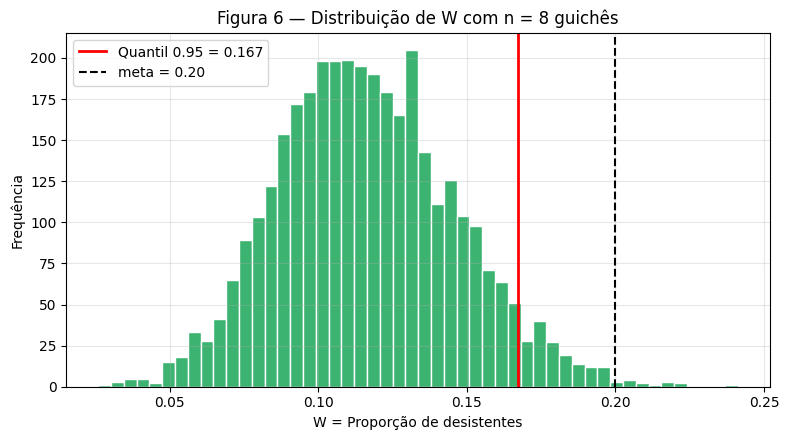

Com n = 8 guichês: quantil 0.95 de W = 0.1673 (<= 0.20)


In [13]:
W_esc = W_por_n[n_escolhido]
q95_esc = np.quantile(W_esc, 0.95)

plt.figure(figsize=(8, 4.5))
plt.hist(W_esc, bins=50, color='mediumseagreen', edgecolor='white')
plt.axvline(q95_esc, color='red', lw=2, label=f'Quantil 0.95 = {q95_esc:.3f}')
plt.axvline(0.20, color='black', ls='--', lw=1.5, label='meta = 0.20')
plt.xlabel("W = Proporção de desistentes")
plt.ylabel("Frequência")
plt.title(f"Figura 6 — Distribuição de W com n = {n_escolhido} guichês")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Com n = {n_escolhido} guichês: quantil 0.95 de W = {q95_esc:.4f} "
      f"({'<=' if q95_esc <= 0.20 else '>'} 0.20)")


### Justificativa (Subproblema 2)

O critério $\Pr(W \le 20\%) \ge 0.95$ equivale a exigir que o **quantil 0.95 da
distribuição de $W$** não ultrapasse 0.20. A tabela impressa acima mostra, para
cada $n$, o quantil 0.95 estimado; o menor $n$ cujo quantil 0.95 fica $\le 0.20$ é
o número de guichês procurado.

A **Figura 5** confirma visualmente a decisão: a curva do quantil 0.95 de $W$ cai
à medida que $n$ aumenta e cruza a linha da meta (0.20) exatamente no $n$
escolhido. A **Figura 6** mostra a distribuição de $W$ para esse $n$, com o quantil
0.95 já dentro da meta — a maior parte da massa de probabilidade fica à esquerda de
0.20.

*(Substitua os valores citados pelo resultado da rodada de vocês.)*